In [1]:
import json

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

n_ticks = 5
line_styles = ['-', '--', ':', '-.', (0, (5, 10)), (0, (5, 1)), (0, (1, 10)), 
          (0, (1, 1)), (0, (3, 5, 1, 5)), (0, (7, 2, 1, 2))]

result_path = Path("diagrams", "temperature_comparison")
result_path.mkdir(exist_ok=True)
n_iterations = 10


In [2]:
# data_set = "folktables_income"
data_set = "gbs_allensbach"
bias_type = "less_positive_class" if data_set == "folktables_income" else "none"
bias_strength = 0.1 if data_set == "folktables_income" else 0.0
method="fw-mrs-temperature"
path = Path(f"../results/temperature_comparison/{data_set}/{bias_type}/{bias_strength}/{method}")
min_number_of_samples = 2895 if data_set == "folktables_income" else 579

## Rf

In [3]:
with open(path / "method_aurocs/optimised_method_aurocs.json") as file:
    auroc_with_feature_weights = json.load(file)[:n_iterations]
    
with open(path / "method_mmds/optimised_method_mmds.json") as file:
    mmd_with_feature_weights = json.load(file)[:n_iterations]
with open(path / "metadata.json") as file:
    metadata = json.load(file)

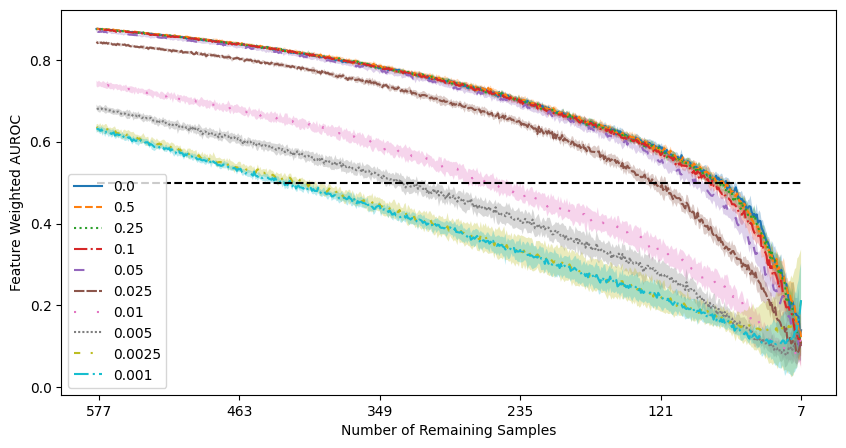

In [4]:
plt.figure(figsize=(10, 5))
min_length = np.min(
    [
        [len(auroc_list) for auroc_list in auroc_lists.values()]
        for auroc_lists in auroc_with_feature_weights
    ]
)
x_labels = list(range(min_number_of_samples, 0, -metadata["n_dropped"]))[:min_length]
for i, budget in enumerate(auroc_with_feature_weights[0].keys()):
    auroc_list = []
    for dictionary in auroc_with_feature_weights:
        dictionary = {float(k): v for k, v in dictionary.items()}
        auroc_list.append(dictionary[float(budget)][:min_length])
    mean_aurocs = np.mean(auroc_list, axis=0)
    std_aurocs = np.std(auroc_list, axis=0)
    ratio_upper = mean_aurocs + std_aurocs
    ratio_lower = (mean_aurocs - std_aurocs).clip(min=0)
    sns.lineplot(
        x=x_labels, y=mean_aurocs, label=str(budget), linestyle=line_styles[i]
    )
    plt.fill_between(x_labels, ratio_lower, ratio_upper, alpha=0.3)
plt.plot(
    [min_number_of_samples, x_labels[-1]], [0.5, 0.5], color="black", linestyle="--"
)
plt.ylabel("Feature Weighted AUROC")
plt.xlabel("Number of Remaining Samples")
step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(result_path / f"optimised_temperature_comparison_rf_auroc_{data_set}.pdf")

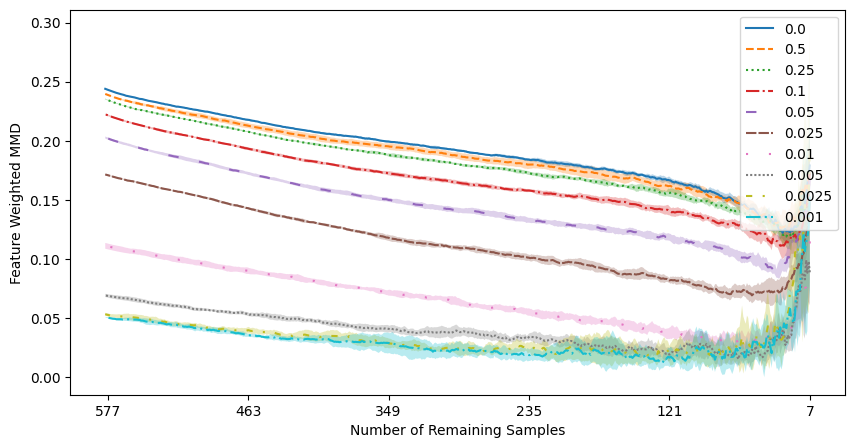

In [5]:
plt.figure(figsize=(10, 5))
min_length = np.min(
    [
        [len(mmd_list) for mmd_list in mmd_lists.values()]
        for mmd_lists in mmd_with_feature_weights
    ]
)
x_labels = list(range(min_number_of_samples, 0, -metadata["n_dropped"]))[:min_length]
for i, budget in enumerate(mmd_with_feature_weights[0].keys()):
    mmd_list = []
    for dictionary in mmd_with_feature_weights:
        dictionary = {float(k): v for k, v in dictionary.items()}
        mmd_list.append(dictionary[float(budget)][:min_length])
    mean_mmds = np.mean(mmd_list, axis=0)
    std_mmds = np.std(mmd_list, axis=0)
    ratio_upper = mean_mmds + std_mmds
    ratio_lower = (mean_mmds - std_mmds).clip(min=0)
    sns.lineplot(
        x=x_labels, y=mean_mmds, label=str(budget), linestyle=line_styles[i]
    )
    plt.fill_between(x_labels, ratio_lower, ratio_upper, alpha=0.3)
plt.ylabel("Feature Weighted MMD")
plt.xlabel("Number of Remaining Samples")
step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(result_path / f"optimised_temperature_comparison_rf_mmd_{data_set}.pdf")

## SVM

In [6]:
method="fw-mrs-temperature-svm"
path = Path(f"../results/temperature_comparison/{data_set}/{bias_type}/{bias_strength}/{method}")
with open(path / "method_aurocs/optimised_method_aurocs.json") as file:
    auroc_with_feature_weights = json.load(file)[:n_iterations]
with open(path / "method_mmds/optimised_method_mmds.json") as file:
    mmd_with_feature_weights = json.load(file)[:n_iterations]

with open(path / "metadata.json") as file:
    metadata = json.load(file)

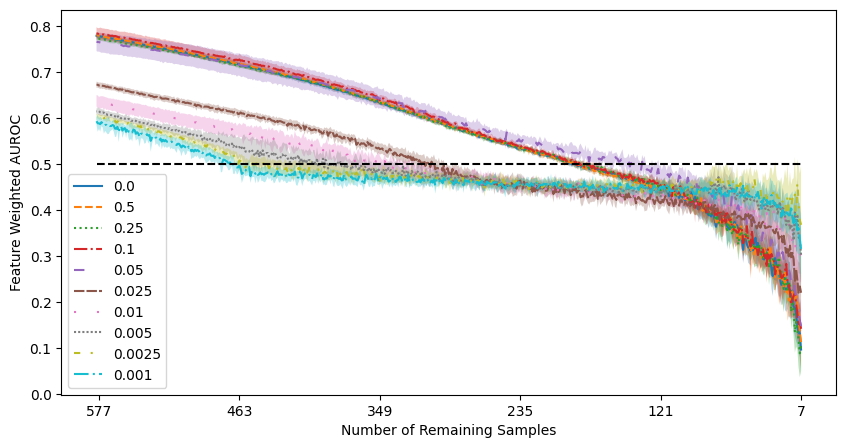

In [7]:
plt.figure(figsize=(10, 5))
min_length = np.min(
    [
        [len(auroc_list) for auroc_list in auroc_lists.values()]
        for auroc_lists in auroc_with_feature_weights
    ]
)
x_labels = list(range(min_number_of_samples, 0, -metadata["n_dropped"]))[:min_length]
for i, budget in enumerate(auroc_with_feature_weights[0].keys()):
    auroc_list = []
    for dictionary in auroc_with_feature_weights:
        dictionary = {float(k): v for k, v in dictionary.items()}
        auroc_list.append(dictionary[float(budget)][:min_length])
    mean_aurocs = np.mean(auroc_list, axis=0)
    std_aurocs = np.std(auroc_list, axis=0)
    ratio_upper = mean_aurocs + std_aurocs
    ratio_lower = (mean_aurocs - std_aurocs).clip(min=0)
    sns.lineplot(
        x=x_labels, y=mean_aurocs, label=str(budget), linestyle=line_styles[i]
    )
    plt.fill_between(x_labels, ratio_lower, ratio_upper, alpha=0.3)
plt.plot(
    [min_number_of_samples, x_labels[-1]], [0.5, 0.5], color="black", linestyle="--"
)
plt.ylabel("Feature Weighted AUROC")
plt.xlabel("Number of Remaining Samples")
step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(result_path / f"optimised_temperature_comparison_svm_auroc_{data_set}.pdf")

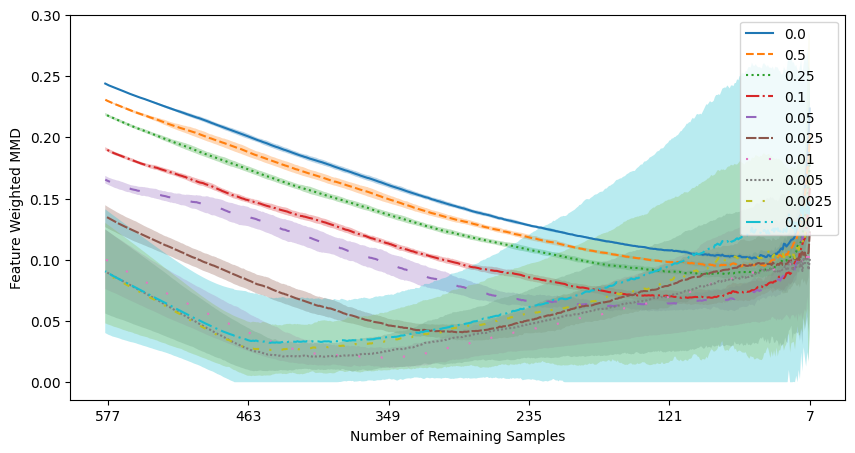

In [8]:
plt.figure(figsize=(10, 5))
min_length = np.min(
    [
        [len(mmd_list) for mmd_list in mmd_lists.values()]
        for mmd_lists in mmd_with_feature_weights
    ]
)
x_labels = list(range(min_number_of_samples, 0, -metadata["n_dropped"]))[:min_length]
for i, budget in enumerate(mmd_with_feature_weights[0].keys()):
    mmd_list = []
    for dictionary in mmd_with_feature_weights:
        dictionary = {float(k): v for k, v in dictionary.items()}
        mmd_list.append(dictionary[float(budget)][:min_length])
    mean_mmds = np.mean(mmd_list, axis=0)
    std_mmds = np.std(mmd_list, axis=0)
    ratio_upper = mean_mmds + std_mmds
    ratio_lower = (mean_mmds - std_mmds).clip(min=0)
    sns.lineplot(
        x=x_labels, y=mean_mmds, label=str(budget), linestyle=line_styles[i]
    )
    plt.fill_between(x_labels, ratio_lower, ratio_upper, alpha=0.3)
plt.ylabel("Feature Weighted MMD")
plt.xlabel("Number of Remaining Samples")
step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(result_path / f"optimised_temperature_comparison_svm_mmd_{data_set}.pdf")